In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
# Set the style to colorblind-friendly
plt.style.use('seaborn-v0_8-colorblind') # Use 'seaborn-colorblind' for older mpl

## Curvas 1

In [16]:

# Caminho da pasta com os CSVs
pasta = "./tests/results/mylib"

# Listas para médias
rows = []

In [17]:
# Ler todos os CSV da pasta
for arquivo in os.listdir(pasta):
    if arquivo.endswith('.csv'):
        parts = arquivo.split('-')
        broadphase = '_'.join(parts[2:4])

        collision = parts[4]
        if collision == 'gjk':
            collision = '_'.join(parts[4:6])
            count = parts[6]
        else:
            count = parts[5]

        if count.isnumeric() == False:
            continue

        caminho = os.path.join(pasta, arquivo)

        df = pd.read_csv(caminho)
        rows.append([
            df["collisionsTest"].mean(), 
            df["broadphaseTime"].mean(),
            df["narrowphaseTime"].mean(),
            df["integrationTime"].mean(),
            df["relaxationTime"].mean(),
            df["separationTime"].mean(),
            df["gridClearTime"].mean(),
            df["gridInitTime"].mean(),
            df["gridSortTime"].mean(),
            df["deltatime"].mean(), 
            int(count), 
            broadphase, 
            collision
        ])

In [18]:
df1 = pd.DataFrame(
    rows, 
    columns=[
        "collisions_test", 
        "broadphase_time",
        "narrowphase_time",
        "integration_time",
        "relaxation_time",
        "separation_time",
        "gridClear_time",
        "gridInit_time",
        "gridSort_time",
        "dt", 
        "count", 
        "broadphase", 
        "narrowphase"
        ]
    )


In [19]:
styles = {
    ("naive_mode", "sat"): {"linestyle": "-", "marker": "o"},
    ("grid_mode", "sat"): {"linestyle": "-", "marker": "o"},
    ("naive_mode", "gjk_epa"): {"linestyle": "--", "marker": "s"},
    ("grid_mode", "gjk_epa"): {"linestyle": "--", "marker": "s"},
}

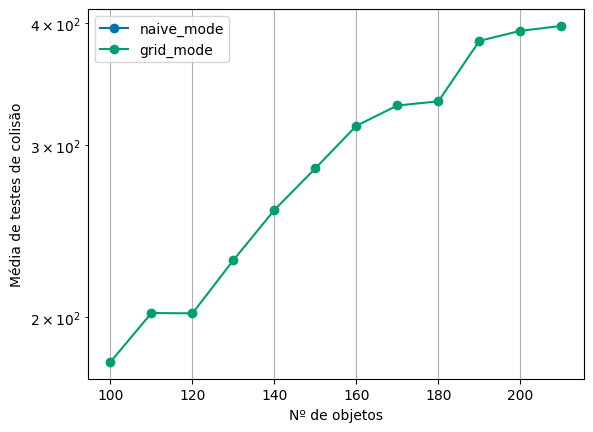

In [20]:
fig, ax = plt.subplots()

for broadphase in ["naive_mode", "grid_mode"]:
    g = df1[
        (df1["broadphase"] == broadphase) & 
        (df1["narrowphase"] == "sat")
    ].sort_values("count")

    style = styles[(broadphase, "sat")]

    ax.plot(
        g["count"],
        g["collisions_test"],
        label=broadphase,
        linestyle=style["linestyle"],
        marker=style["marker"]
    )

ax.set_xlabel("Nº de objetos")
ax.set_ylabel("Média de testes de colisão")
ax.set_yscale("log")
ax.legend()
ax.grid()

plt.show()

## Curvas 2

In [21]:

# Caminho da pasta com os CSVs
pasta = "./tests/results/box2d"

# Listas para médias
rows = []

In [22]:
# Ler todos os CSV da pasta
for arquivo in os.listdir(pasta):
    if arquivo.endswith('.csv'):
        parts = arquivo.split('-')
        count = parts[1]
        if count.isnumeric() is False:
            continue

        caminho = os.path.join(pasta, arquivo)

        df = pd.read_csv(caminho)
        rows.append([
            # df["true_collisions"].mean(), 
            df["dt"].mean(), 
            int(count)
        ])

In [23]:
df2 = pd.DataFrame(rows, columns=["dt", "count"])
df2 = df2.sort_values("count")

In [24]:
df1[
    (df1["narrowphase"] == "sat") & 
    (df1["broadphase"] == "grid_mode")
].sort_values("count")

,collisions_test,broadphase_time,narrowphase_time,integration_time,relaxation_time,separation_time,gridClear_time,gridInit_time,gridSort_time,dt,count,broadphase,narrowphase
1,179.844444,0.097044,0.182259,0.083736,0.852012,0.023270,0.001398,0.073755,0.066304,1.342603,100,grid_mode,sat
4,201.850000,0.112358,0.251408,0.083790,0.852920,0.029121,0.000755,0.076461,0.071978,1.445988,110,grid_mode,sat
9,201.711111,0.118061,0.204317,0.080514,0.892722,0.024327,0.000696,0.058794,0.078585,1.420419,120,grid_mode,sat
5,228.733333,0.135877,0.273979,0.096507,1.021681,0.029577,0.000822,0.066748,0.092659,1.658305,130,grid_mode,sat
8,257.472222,0.143584,0.248611,0.091304,0.958979,0.032796,0.000841,0.074034,0.093095,1.597573,140,grid_mode,sat
2,284.088889,0.154488,0.308678,0.103143,1.118653,0.037620,0.000853,0.082002,0.097239,1.852132,150,grid_mode,sat
0,314.077778,0.158136,0.337992,0.116881,1.113082,0.039826,0.000938,0.080502,0.100969,1.903222,160,grid_mode,sat
11,329.466667,0.171240,0.352804,0.117962,1.218618,0.033325,0.000971,0.090562,0.110692,2.038145,170,grid_mode,sat
6,332.722222,0.186816,0.416844,0.139527,1.425817,0.023795,0.001230,0.110632,0.124377,2.367492,180,grid_mode,sat
10,383.811111,0.191759,0.377523,0.128826,1.287958,0.025004,0.000876,0.099189,0.127697,2.162649,190,grid_mode,sat


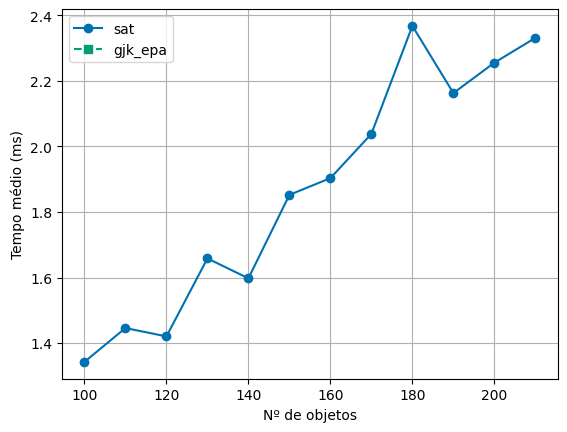

In [26]:
fig, ax = plt.subplots()

for narrowphase in ["sat", "gjk_epa"]:
    g = df1[
            (df1["narrowphase"] == narrowphase) & 
            (df1["broadphase"] == "grid_mode")
        ].sort_values("count")
    
    style = styles[("grid_mode", narrowphase)]
    ax.plot(
        g["count"],
        g["dt"],
        label=narrowphase,
        linestyle=style["linestyle"],
        marker=style["marker"]
    )

# ax.plot(df2["count"], df2["dt"], label="planckjs", marker="o")

ax.set_xlabel("Nº de objetos")
ax.set_ylabel("Tempo médio (ms)")
# ax.set_yscale("log")
ax.legend()
ax.grid()

plt.show()

## Curvas 3

In [ ]:
cols = [
    "narrowphase_time",
    "broadphase_time",
    "relaxation_time",
    "integration_time",
    "separation_time",
    "gridInit_time",
    "gridSort_time",
    "gridClear_time",
]

g = df1[
    (df1["broadphase"] == "grid_mode") & 
    (df1["narrowphase"] == "sat")
].sort_values("count")

# calcula porcentagens de uma vez
rel = g[cols].div(g["dt"], axis=0) * 100

# padrões (hatches) distintos
hatches = ['//', '\\\\', 'xx', '--', '++', 'oo', '..', '**']

x = g["count"].values
y = rel.values.T  # necessário para stackplot

fig, ax = plt.subplots(figsize=(10, 6))

# gráfico empilhado manual (permite mais controle)
stacks = ax.stackplot(x, y, edgecolor='black')

# aplica hatches
for poly, hatch in zip(stacks, hatches):
    poly.set_hatch(hatch)
    poly.set_alpha(0.9)

ax.legend(stacks, cols)

ax.set_xlabel("Nº de objetos")
ax.set_ylabel("% do tempo total")

# plt.tight_layout()
plt.show()